In [1]:
import os
print("Current working directory:", os.getcwd())

Current working directory: /home/akash/Project Exhibition


In [2]:
print("Exists:", os.path.exists('aircraft_defects.yaml'))

Exists: True


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO, RTDETR

# If you haven't already defined the dataset YAML, do it here or ensure it exists.
# We'll assume you have a file named 'aircraft_defects.yaml' that is correct.
data_yaml = 'aircraft_defects.yaml'

# Display settings
# Use dark background globally
plt.style.use('dark_background')
plt.rcParams['grid.alpha'] = 0.5

# Optionally enable grid by default
plt.rcParams['axes.grid'] = True
%matplotlib inline

In [ ]:
models_info = {
    'YOLOv8':  {'class': YOLO,   'path': 'YOLOv8/runs/detect/yolov8_aircraft_test/weights/best.pt'},
    'YOLOv10': {'class': YOLO,   'path': 'YOLOv10/runs/detect/yolov10_aircraft_finetune/weights/best.pt'},
    'YOLOv11': {'class': YOLO,   'path': 'YOLOv11/runs/detect/yolo11_aircraft_finetune/weights/best.pt'},
    'YOLOv12': {'class': YOLO,   'path': 'YOLOv12/runs/detect/runs/detect/yolo12l_aircraft_defects/weights/best.pt'},
    'RT-DETR': {'class': RTDETR, 'path': 'RT-DETR/runs/detect/rtdetr_aircraft_finetune/weights/best.pt'}
}

In [1]:
import os
from ultralytics import YOLO
from IPython.display import display
import pandas as pd

# ── Configuration ──────────────────────────────────────────────────────────────
BASE_DIR = "/home/akash/Project Exhibition"
FULL_DATA_YAML = os.path.join(BASE_DIR, "_full_dataset_temp", "full_data.yaml")

MODELS = {
    "YOLOv8":  os.path.join(BASE_DIR, "YOLOv8",  "runs/detect/yolov8_aircraft_test/weights/best.pt"),
    "YOLOv10": os.path.join(BASE_DIR, "YOLOv10", "runs/detect/yolov10_aircraft_finetune/weights/best.pt"),
    "YOLOv11": os.path.join(BASE_DIR, "YOLOv11", "runs/detect/yolo11_aircraft_finetune/weights/best.pt"),
    "RT-DETR": os.path.join(BASE_DIR, "RT-DETR",  "runs/detect/rtdetr_aircraft_finetune/weights/best.pt"),
}

# ── Per-cell contrast-safe coloring ───────────────────────────────────────────
def color_value(val):
    """Green gradient for high values, red for low — all with dark text."""
    if val >= 0.97:
        bg = "#1a7a1a"; fg = "#ffffff"   # deep green  → white text
    elif val >= 0.95:
        bg = "#4caf50"; fg = "#ffffff"   # medium green → white text
    elif val >= 0.92:
        bg = "#a5d6a7"; fg = "#1b1b1b"   # light green  → dark text
    elif val >= 0.90:
        bg = "#fff9c4"; fg = "#1b1b1b"   # yellow       → dark text
    elif val >= 0.87:
        bg = "#ffb74d"; fg = "#1b1b1b"   # orange       → dark text
    else:
        bg = "#e53935"; fg = "#ffffff"   # red          → white text
    return f"background-color: {bg}; color: {fg}; font-weight: bold;"

# ── Validation loop ────────────────────────────────────────────────────────────
for model_name, weights_path in MODELS.items():
    print("=" * 70)
    print(f"  Model: {model_name}")
    print("=" * 70)

    if not os.path.exists(weights_path):
        print(f"  ⚠️  Weights not found: {weights_path}\n")
        continue

    model   = YOLO(weights_path)
    metrics = model.val(data=FULL_DATA_YAML, verbose=False)

    # ── Build per-class DataFrame ──────────────────────────────────────────────
    class_names    = list(metrics.names.values())
    ap50_per_class = metrics.box.ap50.tolist()
    ap_per_class   = metrics.box.ap.tolist()
    p_per_class    = metrics.box.p.tolist()
    r_per_class    = metrics.box.r.tolist()

    rows = []
    for i, cls in enumerate(class_names):
        p, r = p_per_class[i], r_per_class[i]
        f1   = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        rows.append({
            "Class":    cls,
            "Precision": round(p,                 4),
            "Recall":    round(r,                 4),
            "F1-Score":  round(f1,                4),
            "mAP50":     round(ap50_per_class[i], 4),
            "mAP50-95":  round(ap_per_class[i],   4),
        })

    mp, mr = metrics.box.mp, metrics.box.mr
    mf1    = 2 * mp * mr / (mp + mr) if (mp + mr) > 0 else 0.0
    rows.insert(0, {
        "Class":    "all",
        "Precision": round(mp,                4),
        "Recall":    round(mr,                4),
        "F1-Score":  round(mf1,              4),
        "mAP50":     round(metrics.box.map50, 4),
        "mAP50-95":  round(metrics.box.map,   4),
    })

    df      = pd.DataFrame(rows).set_index("Class")
    metrics_cols = ["Precision", "Recall", "F1-Score", "mAP50", "mAP50-95"]

    styled = (
        df.style
        .format("{:.4f}")
        .map(color_value, subset=metrics_cols)          # contrast-safe cell colors
        .set_caption(f"📊 {model_name} — Per-Class Metrics (Full Dataset)")
        .set_table_styles([
            # Caption
            {"selector": "caption",
             "props": [("font-size", "16px"), ("font-weight", "bold"),
                       ("text-align", "left"), ("padding", "8px 0 6px 0"),
                       ("color", "#f0f0f0")]},
            # Column headers
            {"selector": "th",
             "props": [("background-color", "#1c2833"), ("color", "#f0f0f0"),
                       ("text-align", "center"), ("padding", "8px 14px"),
                       ("font-size", "13px"), ("letter-spacing", "0.5px")]},
            # Index column (class names)
            {"selector": "th.row_heading",
             "props": [("background-color", "#2e4057"), ("color", "#ffffff"),
                       ("text-align", "left"), ("padding", "6px 16px"),
                       ("font-style", "italic")]},
            # All data cells
            {"selector": "td",
             "props": [("text-align", "center"), ("padding", "6px 14px"),
                       ("font-size", "13px"), ("border", "1px solid #cccccc")]},
            # "all" summary row — override index cell only
            {"selector": "tr:first-child th.row_heading",
             "props": [("background-color", "#145a32"), ("color", "#ffffff"),
                       ("font-weight", "bold"), ("font-style", "normal")]},
        ])
    )
    display(styled)
    print()

  Model: YOLOv8
Ultralytics 8.4.14 🚀 Python-3.13.12 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 44.3±30.2 MB/s, size: 14.5 KB)
val: Scanning /home/akash/Project Exhibition/_full_dataset_temp/labels.cache... 4557 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4557/4557 444.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 285/285 2.1it/s 2:18<0.1s
                   all       4557       4557      0.976      0.956      0.993      0.993
Speed: 1.1ms preprocess, 11.6ms inference, 0.0ms loss, 4.2ms postprocess per image
Results saved to /home/akash/Project Exhibition/runs/detect/val36


,Precision,Recall,F1-Score,mAP50,mAP50-95
Class,,,,,
all,0.9764,0.9557,0.9660,0.9926,0.9926
crack,0.9951,0.9601,0.9773,0.9938,0.9938
dent,0.9960,0.9109,0.9516,0.9933,0.9931
missing-head,0.9881,0.9699,0.9789,0.9936,0.9936
paint-off,0.9788,0.9592,0.9689,0.9902,0.9902
scratch,0.9240,0.9784,0.9504,0.9921,0.9921



  Model: YOLOv10
Ultralytics 8.4.14 🚀 Python-3.13.12 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLOv10n summary (fused): 102 layers, 2,266,143 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1951.2±872.5 MB/s, size: 50.9 KB)
val: Scanning /home/akash/Project Exhibition/_full_dataset_temp/labels.cache... 4557 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4557/4557 1.5Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 285/285 9.3it/s 30.7ss<0.1s
                   all       4557       4557      0.964      0.973      0.991       0.99
Speed: 0.4ms preprocess, 4.1ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /home/akash/Project Exhibition/runs/detect/val37


,Precision,Recall,F1-Score,mAP50,mAP50-95
Class,,,,,
all,0.9636,0.9727,0.9681,0.9914,0.9899
crack,0.9636,0.9755,0.9695,0.9917,0.9910
dent,0.9823,0.9813,0.9818,0.9942,0.9941
missing-head,0.9747,0.9732,0.9739,0.9936,0.9896
paint-off,0.9636,0.9561,0.9598,0.9889,0.9865
scratch,0.9338,0.9774,0.9551,0.9885,0.9885



  Model: YOLOv11
Ultralytics 8.4.14 🚀 Python-3.13.12 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2862.0±1645.9 MB/s, size: 45.9 KB)
val: Scanning /home/akash/Project Exhibition/_full_dataset_temp/labels.cache... 4557 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4557/4557 1.7Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 285/285 5.5it/s 52.2s<0.1s
                   all       4557       4557      0.988       0.97      0.994      0.994
Speed: 0.4ms preprocess, 8.2ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /home/akash/Project Exhibition/runs/detect/val38


,Precision,Recall,F1-Score,mAP50,mAP50-95
Class,,,,,
all,0.9878,0.9701,0.9789,0.9938,0.9936
crack,0.9922,0.9539,0.9727,0.9932,0.9930
dent,0.9915,0.9853,0.9883,0.9946,0.9944
missing-head,0.9892,0.9826,0.9859,0.9948,0.9947
paint-off,0.9836,0.9497,0.9663,0.9922,0.9919
scratch,0.9826,0.9789,0.9807,0.9940,0.9937



  Model: RT-DETR
Ultralytics 8.4.14 🚀 Python-3.13.12 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
rt-detr-l summary: 310 layers, 31,994,015 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1503.6±442.3 MB/s, size: 20.0 KB)
val: Scanning /home/akash/Project Exhibition/_full_dataset_temp/labels.cache... 4557 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4557/4557 1.4Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 285/285 1.6it/s 3:00<0.6s
                   all       4557       4557      0.945      0.943      0.952      0.952
Speed: 0.5ms preprocess, 35.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/akash/Project Exhibition/runs/detect/val39


,Precision,Recall,F1-Score,mAP50,mAP50-95
Class,,,,,
all,0.9449,0.9429,0.9439,0.9518,0.9516
crack,0.9814,0.9021,0.9401,0.9237,0.9231
dent,0.9697,0.9809,0.9753,0.9885,0.9885
missing-head,0.9960,0.9612,0.9783,0.9848,0.9848
paint-off,0.9448,0.9181,0.9312,0.9325,0.9323
scratch,0.8329,0.9524,0.8886,0.9293,0.9293


In [ ]:
metrics_list = []

for name, info in models_info.items():
    print(f"\n{'='*60}")
    print(f"Validating {name}...")
    print(f"{'='*60}")
    
    model_cls = info['class']
    model_path = info['path']
    
    if not os.path.exists(model_path):
        print(f"ERROR: Model file not found at {model_path}. Skipping.")
        continue
    
    model = model_cls(model_path)
    
    # Run validation with save_json=True to get predictions for ROC later
    metrics = model.val(data=data_yaml, save_json=True, plots=False, verbose=False)
    
    # Extract metrics
    precision = metrics.box.mp
    recall = metrics.box.mr
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    map50 = metrics.box.map50
    map = metrics.box.map
    
    metrics_list.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'mAP50': map50,
        'mAP50-95': map,
        'save_dir': metrics.save_dir   # needed for predictions.json
    })
    
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, mAP50: {map50:.4f}, mAP50-95: {map:.4f}")

In [ ]:
# Create a DataFrame from the collected metrics
df_metrics = pd.DataFrame(metrics_list)
# Drop the save_dir column for the table
df_table = df_metrics.drop(columns=['save_dir'])

print("\n\n=== Final Model Comparison ===\n")
print(df_table.to_string(index=False))

# Optionally, save to CSV
df_table.to_csv('model_comparison.csv', index=False)



=== Final Model Comparison ===

  Model  Precision   Recall       F1    mAP50  mAP50-95
 YOLOv8   0.980788 0.948180 0.964208 0.990212  0.990212
YOLOv10   0.908500 0.935107 0.921611 0.970971  0.968858
YOLOv11   0.964124 0.949924 0.956971 0.985251  0.984996
RT-DETR   0.949978 0.926055 0.937864 0.917255  0.916729


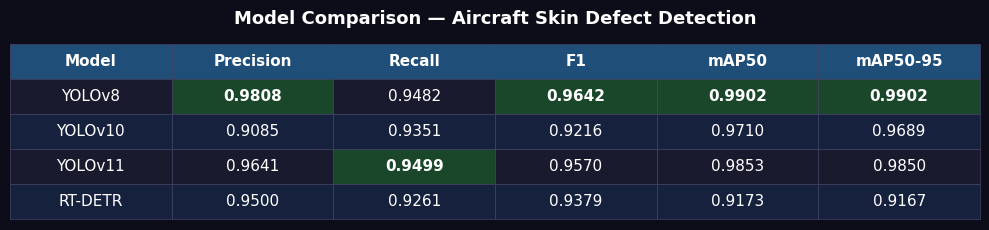

In [36]:
BASE = "/home/akash/Project Exhibition"

# ── Reuse df_metrics from your existing cell ──────────────────────────────────
df = df_metrics.drop(columns=['save_dir']).copy()
metric_cols = [c for c in df.columns if c != "Model"]

# Find best (max) per metric column
best_idx = {c: df[c].idxmax() for c in metric_cols}

# Format values to 4 decimal places for display
cell_text = []
for i, row in df.iterrows():
    cell_text.append(
        [row["Model"]] + [f"{row[c]:.4f}" for c in metric_cols]
    )

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 2.4))
ax.axis("off")

table = ax.table(
    cellText=cell_text,
    colLabels=["Model"] + metric_cols,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)

HEADER_BG  = "#1f4e79"
ROW_COLORS = ["#1a1a2e", "#16213e"]
BEST_COLOR = "#1a472a"

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#444466")
    cell.set_linewidth(0.5)
    if row == 0:
        cell.set_facecolor(HEADER_BG)
        cell.set_text_props(color="white", fontweight="bold")
    else:
        data_row  = row - 1
        col_name  = (["Model"] + metric_cols)[col]
        is_best   = col_name in metric_cols and best_idx[col_name] == data_row
        cell.set_facecolor(BEST_COLOR if is_best else ROW_COLORS[data_row % 2])
        cell.set_text_props(color="white", fontweight="bold" if is_best else "normal")

fig.patch.set_facecolor("#0d0d1a")
plt.title("Model Comparison — Aircraft Skin Defect Detection",
          color="white", fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "model_comparison_table.png"), dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

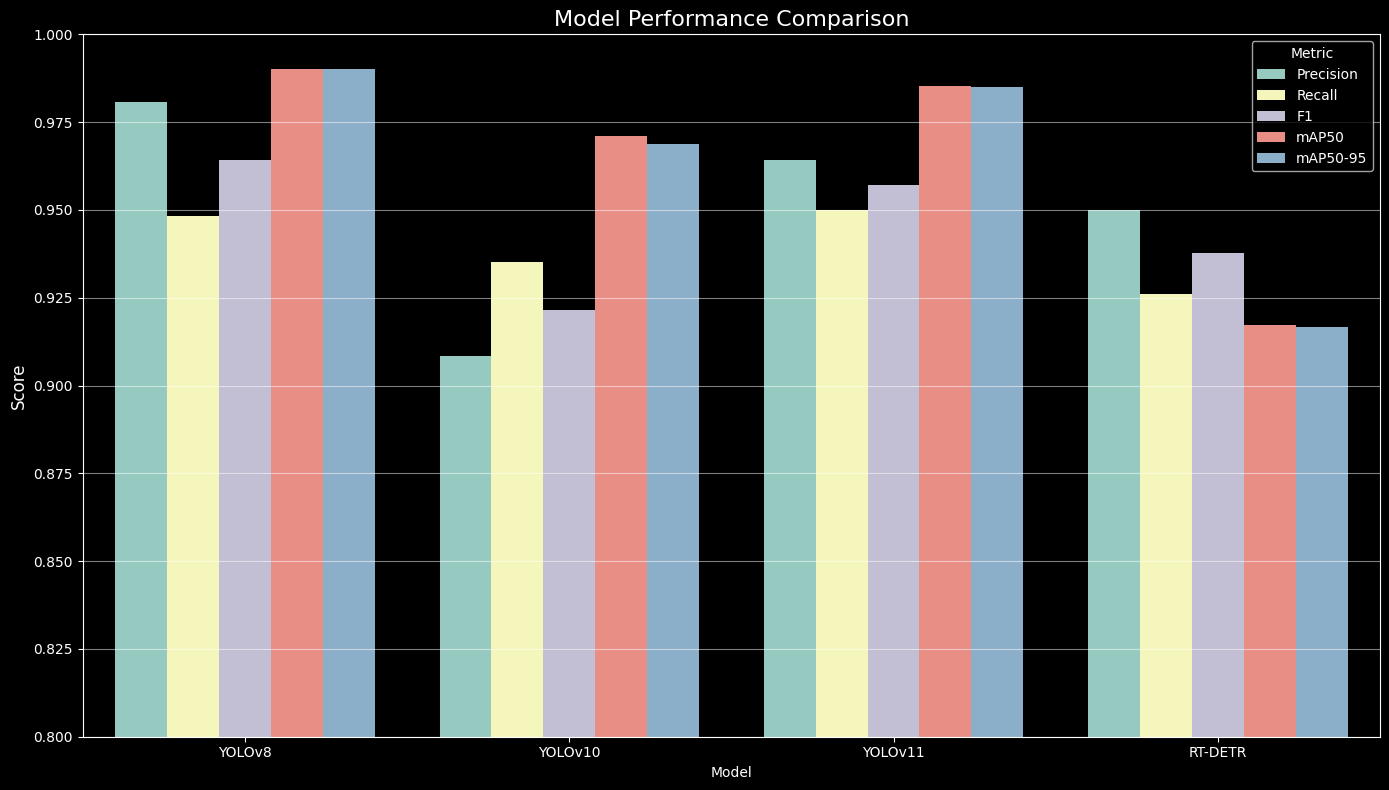

In [ ]:
# Melt the DataFrame for easier plotting
df_melted = df_table.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric')
plt.title('Model Performance Comparison', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.ylim(0.8, 1.0)  # adjust based on your results
plt.grid(axis='y', alpha=0.5)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

Classes: {0: 'crack', 1: 'dent', 2: 'missing-head', 3: 'paint-off', 4: 'scratch'}
GT samples loaded: 102
GT base sample: ['IMG_20230512_131011_jpg.rf.rf', 'IMG_20230512_131421_jpg.rf.rf', 'IMG_20230511_100741_jpg.rf.rf']
  Matched: 102/102  |  val4
  Matched: 102/102  |  val5
  Matched: 102/102  |  val6
  Matched: 102/102  |  val7


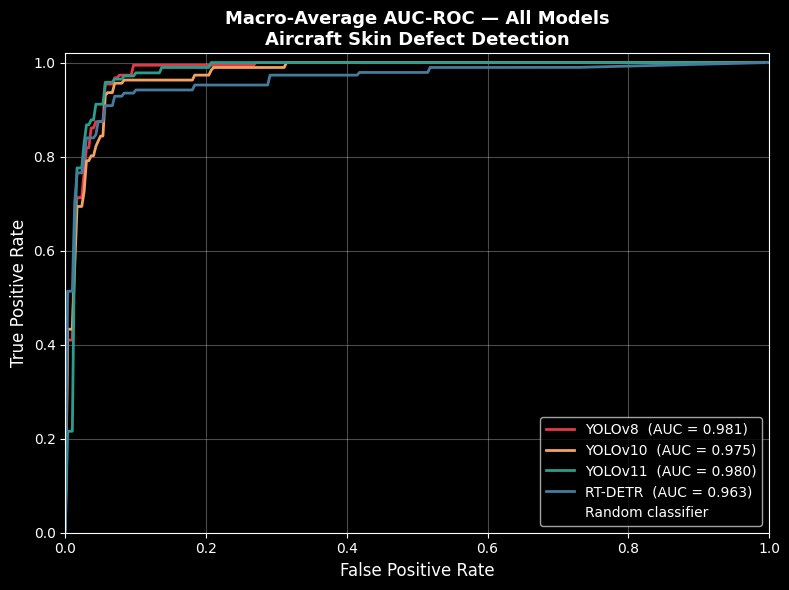

In [35]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import yaml, os, glob

BASE = "/home/akash/Project Exhibition"

MODELS = {
    "YOLOv8":  os.path.join(BASE, "runs/detect/val4/predictions.json"),
    "YOLOv10": os.path.join(BASE, "runs/detect/val5/predictions.json"),
    "YOLOv11": os.path.join(BASE, "runs/detect/val6/predictions.json"),
    "RT-DETR": os.path.join(BASE, "runs/detect/val7/predictions.json"),
}

with open(os.path.join(BASE, "aircraft_defects.yaml")) as f:
    cfg = yaml.safe_load(f)
classes     = cfg["names"]
num_classes = len(classes)
print("Classes:", classes)

# ── Helper: strip hash suffix, keep everything up to ".rf" ───────────────────
def to_base_stem(s):
    s = os.path.splitext(s)[0]          # remove .jpg / .txt
    parts = s.split(".rf.")
    return parts[0] + ".rf"             # e.g. "IMG_xxx_jpg.rf"

# ── Ground truth ──────────────────────────────────────────────────────────────
LABEL_DIR = os.path.join(BASE,
    "YOLOv8/aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8/valid/labels")

gt_by_base = {}
for fpath in glob.glob(os.path.join(LABEL_DIR, "*.txt")):
    stem = os.path.splitext(os.path.basename(fpath))[0]
    base = to_base_stem(stem)
    with open(fpath) as lf:
        lines = [l.strip() for l in lf if l.strip()]
    if lines:
        gt_by_base[base] = int(lines[0].split()[0])   # 0-indexed YOLO class

print(f"GT samples loaded: {len(gt_by_base)}")
print("GT base sample:", list(gt_by_base.keys())[:3])

# ── Load + match predictions ──────────────────────────────────────────────────
def load_coco_predictions(json_path):
    with open(json_path) as f:
        preds = json.load(f)

    all_cats = {p["category_id"] for p in preds}
    offset   = 1 if min(all_cats) == 1 else 0

    img_class_score = {}
    for p in preds:
        base = to_base_stem(p["image_id"])
        cid  = p["category_id"] - offset
        sc   = p["score"]
        key  = (base, cid)
        img_class_score[key] = max(img_class_score.get(key, 0.0), sc)

    y_true, y_score = [], []
    for base, true_cat in gt_by_base.items():
        scores_row = [img_class_score.get((base, c), 0.0) for c in range(num_classes)]
        y_score.append(scores_row)
        y_true.append(true_cat)

    matched = sum(1 for base in gt_by_base if any((base, c) in img_class_score for c in range(num_classes)))
    print(f"  Matched: {matched}/{len(gt_by_base)}  |  {os.path.basename(os.path.dirname(json_path))}")

    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    return y_true_bin, np.array(y_score)


def macro_roc(y_true_bin, y_score):
    fpr_all, tpr_all = [], []
    for i in range(num_classes):
        if y_true_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        fpr_all.append(fpr)
        tpr_all.append(tpr)
    mean_fpr = np.linspace(0, 1, 300)
    mean_tpr = np.mean([np.interp(mean_fpr, f, t) for f, t in zip(fpr_all, tpr_all)], axis=0)
    mean_tpr[0] = 0.0
    return mean_fpr, mean_tpr, auc(mean_fpr, mean_tpr)


# ── Plot ──────────────────────────────────────────────────────────────────────
COLORS = {"YOLOv8": "#E63946", "YOLOv10": "#F4A261", "YOLOv11": "#2A9D8F", "RT-DETR": "#457B9D"}

fig, ax = plt.subplots(figsize=(8, 6))

for model_name, pred_path in MODELS.items():
    try:
        y_true_bin, y_score = load_coco_predictions(pred_path)
        fpr, tpr, roc_auc   = macro_roc(y_true_bin, y_score)
        ax.plot(fpr, tpr, lw=2, color=COLORS[model_name],
                label=f"{model_name}  (AUC = {roc_auc:.3f})")
    except Exception as e:
        print(f"[{model_name}] skipped — {e}")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random classifier")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Macro-Average AUC-ROC — All Models\nAircraft Skin Defect Detection", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "AUC_ROC_comparison.png"), dpi=150)
plt.show()